**<h1>TASK 1 - DATA CLEANING AND VALIDATION</h1>**

In [4]:
import pandas as pd
import numpy as np

sorties = pd.read_csv("airman_dataset/sorties.csv")

sorties.head()

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type
0,S001,C007,I013,A002,B02,2026-05-04 19:00:00,2026-05-04 20:30:00,2026-05-04 19:01:00,2026-05-04 20:31:00,completed,1,NaN,Navigation
1,S002,C021,I013,A001,B02,2026-05-08 21:00:00,2026-05-08 22:30:00,2026-05-08 21:09:00,2026-05-08 22:39:00,completed,9,NaN,Circuit
2,S003,C034,I007,A010,B01,2026-05-04 21:00:00,2026-05-04 22:30:00,2026-05-04 21:39:00,2026-05-04 23:09:00,completed,39,NaN,Instrument
3,S004,C040,I011,A004,B02,2026-05-13 16:00:00,2026-05-13 17:30:00,2026-05-13 16:29:00,2026-05-13 17:59:00,completed,29,NaN,Cross Country
4,S005,C017,I008,A005,B01,2026-05-11 04:00:00,2026-05-11 05:30:00,NaN,NaN,cancelled,0,Aircraft Defect,Navigation


In [5]:
date_cols = [
    "scheduled_start",
    "scheduled_end",
    "actual_start",
    "actual_end"
]

for col in date_cols:
    sorties[col] = pd.to_datetime(sorties[col], errors="coerce")

sorties.head()

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type
0,S001,C007,I013,A002,B02,2026-05-04 19:00:00,2026-05-04 20:30:00,2026-05-04 19:01:00,2026-05-04 20:31:00,completed,1,NaN,Navigation
1,S002,C021,I013,A001,B02,2026-05-08 21:00:00,2026-05-08 22:30:00,2026-05-08 21:09:00,2026-05-08 22:39:00,completed,9,NaN,Circuit
2,S003,C034,I007,A010,B01,2026-05-04 21:00:00,2026-05-04 22:30:00,2026-05-04 21:39:00,2026-05-04 23:09:00,completed,39,NaN,Instrument
3,S004,C040,I011,A004,B02,2026-05-13 16:00:00,2026-05-13 17:30:00,2026-05-13 16:29:00,2026-05-13 17:59:00,completed,29,NaN,Cross Country
4,S005,C017,I008,A005,B01,2026-05-11 04:00:00,2026-05-11 05:30:00,NaT,NaT,cancelled,0,Aircraft Defect,Navigation


In [8]:
missing=sorties.isnull().sum()
print(missing)

sortie_id           0
cadet_id            0
instructor_id       0
aircraft_id         0
base_id             0
scheduled_start     0
scheduled_end       0
actual_start       18
actual_end         18
status              0
delay_minutes       0
cancel_reason      82
lesson_type         0
dtype: int64


In [12]:
duplicate_sorties = sorties[sorties.duplicated(subset=['sortie_id'], keep=False)]
duplicate_sorties

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type


In [11]:
invalid_schedule_times = sorties[
    sorties['scheduled_end'] < sorties['scheduled_start']
]
invalid_schedule_times

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type


In [13]:
invalid_actual_times = sorties[
    sorties['actual_end'] < sorties['actual_start']
]
invalid_actual_times

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type


In [17]:
valid_statuses = ['completed', 'cancelled', 'delayed', 'scheduled']

invalid_status = sorties[~sorties['status'].isin(valid_statuses)]
invalid_status

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type


In [18]:
completed_missing_actuals = sorties[
    (sorties['status'] == 'completed') &
    (
        sorties['actual_start'].isnull() |
        sorties['actual_end'].isnull()
    )
]
completed_missing_actuals

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type


In [19]:
cancelled_with_actuals = sorties[
    (sorties['status'] == 'cancelled') &
    (
        sorties['actual_start'].notnull() |
        sorties['actual_end'].notnull()
    )
]
cancelled_with_actuals

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type


In [21]:
# Calculate delay using:
# 1. Start delay if flight started late
# 2. Else use end delay if flight ended late

sorties['calculated_delay'] = (
    (
        sorties['actual_start'] - sorties['scheduled_start']
    ).dt.total_seconds() / 60
).fillna(0)

end_delay = (
    (
        sorties['actual_end'] - sorties['scheduled_end']
    ).dt.total_seconds() / 60
).fillna(0)

sorties.loc[
    sorties['calculated_delay'] == 0,
    'calculated_delay'
] = end_delay


delay_mismatch = sorties[
    sorties['calculated_delay'] != sorties['delay_minutes']
]

delay_mismatch[['sortie_id', 'delay_minutes', 'calculated_delay']]

,sortie_id,delay_minutes,calculated_delay


In [22]:
negative_delay = sorties[
    sorties['delay_minutes'] < 0
]

negative_delay

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type,calculated_delay


In [23]:
sorties['actual_duration_minutes'] = (
    sorties['actual_end'] - sorties['actual_start']
).dt.total_seconds() / 60

invalid_duration = sorties[
    (sorties['actual_duration_minutes'] <= 0) |
    (sorties['actual_duration_minutes'] > 600)
]

invalid_duration

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type,calculated_delay,actual_duration_minutes


In [24]:
missing_cancel_reason = sorties[
    (sorties['status'] == 'cancelled') &
    (sorties['cancel_reason'].isnull())
]

missing_cancel_reason

,sortie_id,cadet_id,instructor_id,aircraft_id,base_id,scheduled_start,scheduled_end,actual_start,actual_end,status,delay_minutes,cancel_reason,lesson_type,calculated_delay,actual_duration_minutes


In [26]:
cancelled_with_actuals = sorties[
    (sorties['status'] == 'cancelled') &
    (
        sorties['actual_start'].notna() |
        sorties['actual_end'].notna()
    )
]

cancelled_with_actuals[['sortie_id', 'status', 'actual_start', 'actual_end']]

,sortie_id,status,actual_start,actual_end


In [28]:
import re

aircraft = pd.read_csv("airman_dataset/aircraft.csv")

print("\n========== MISSING VALUES ==========")
print(aircraft.isnull().sum())


print("\n========== DUPLICATE AIRCRAFT IDS ==========")
duplicate_aircraft = aircraft[
    aircraft.duplicated(subset="aircraft_id", keep=False)
]
print(duplicate_aircraft)


print("\n========== INVALID REGISTRATION VALUES ==========")

invalid_registration = aircraft[
    ~aircraft["registration"].astype(str).str.match(r"^VT-[A-Z]{3}$")
]

print(invalid_registration)


print("\n========== NEGATIVE AVAILABLE HOURS ==========")

negative_available_hours = aircraft[
    aircraft["total_available_hours"] < 0
]

print(negative_available_hours)


print("\n========== NEGATIVE MAINTENANCE DOWNTIME HOURS ==========")

negative_downtime = aircraft[
    aircraft["maintenance_downtime_hours"] < 0
]

print(negative_downtime)


print("\n========== NEGATIVE DEFECT COUNTS ==========")

negative_defects = aircraft[
    aircraft["defect_count"] < 0
]

print(negative_defects)


print("\n========== DOWNTIME GREATER THAN AVAILABLE HOURS ==========")

invalid_downtime = aircraft[
    aircraft["maintenance_downtime_hours"] >
    aircraft["total_available_hours"]
]

print(invalid_downtime)


print("\n========== UNUSUALLY HIGH DEFECT COUNTS ==========")

high_defects = aircraft[
    aircraft["defect_count"] > 10
]

print(high_defects)


print("\n========== INVALID AIRCRAFT TYPES ==========")

valid_aircraft_types = ["C172", "PA28", "DA40", "C152", "SR20"]

invalid_aircraft_types = aircraft[
    ~aircraft["type"].isin(valid_aircraft_types)
]

print(invalid_aircraft_types)


========== MISSING VALUES ==========
aircraft_id                   0
registration                  0
type                          0
base_id                       0
total_available_hours         0
maintenance_downtime_hours    0
defect_count                  0
dtype: int64

========== DUPLICATE AIRCRAFT IDS ==========
Empty DataFrame
Columns: [aircraft_id, registration, type, base_id, total_available_hours, maintenance_downtime_hours, defect_count]
Index: []

========== INVALID REGISTRATION VALUES ==========
Empty DataFrame
Columns: [aircraft_id, registration, type, base_id, total_available_hours, maintenance_downtime_hours, defect_count]
Index: []

========== NEGATIVE AVAILABLE HOURS ==========
Empty DataFrame
Columns: [aircraft_id, registration, type, base_id, total_available_hours, maintenance_downtime_hours, defect_count]
Index: []

========== NEGATIVE MAINTENANCE DOWNTIME HOURS ==========
Empty DataFrame
Columns: [aircraft_id, registration, type, base_id, total_available_hours, m

In [29]:
cadets = pd.read_csv("airman_dataset/cadets.csv")


print("\n========== CONVERT DATE TO CORRECT FORMAT ==========")

cadets["enrollment_date"] = pd.to_datetime(
    cadets["enrollment_date"],
    errors="coerce"
)

print(cadets["enrollment_date"].head())


print("\n========== MISSING VALUES ==========")

print(cadets.isnull().sum())


print("\n========== DUPLICATE CADET IDS ==========")

duplicate_cadets = cadets[
    cadets.duplicated(subset="cadet_id", keep=False)
]

print(duplicate_cadets)


print("\n========== INVALID COURSE VALUES ==========")

valid_courses = ["PPL", "CPL", "IR"]

invalid_courses = cadets[
    ~cadets["course"].isin(valid_courses)
]

print(invalid_courses)


print("\n========== NEGATIVE REQUIRED HOURS ==========")

negative_required_hours = cadets[
    cadets["total_required_hours"] < 0
]

print(negative_required_hours)


print("\n========== NEGATIVE FLOWN HOURS ==========")

negative_flown_hours = cadets[
    cadets["total_flown_hours"] < 0
]

print(negative_flown_hours)


print("\n========== FLOWN HOURS GREATER THAN REQUIRED HOURS ==========")

invalid_flown_hours = cadets[
    cadets["total_flown_hours"] >
    cadets["total_required_hours"]
]

print(invalid_flown_hours)


print("\n========== INVALID ENROLLMENT DATES ==========")

invalid_dates = cadets[
    cadets["enrollment_date"].isna()
]

print(invalid_dates)


print("\n========== FUTURE ENROLLMENT DATES ==========")

future_dates = cadets[
    cadets["enrollment_date"] > pd.Timestamp.today()
]

print(future_dates)


========== CONVERT DATE TO CORRECT FORMAT ==========
0   2025-11-03
1   2025-08-24
2   2026-01-24
3   2026-02-13
4   2025-07-13
Name: enrollment_date, dtype: datetime64[ns]

========== MISSING VALUES ==========
cadet_id                0
name                    0
course                  0
home_base               0
total_required_hours    0
total_flown_hours       0
enrollment_date         0
dtype: int64

========== DUPLICATE CADET IDS ==========
Empty DataFrame
Columns: [cadet_id, name, course, home_base, total_required_hours, total_flown_hours, enrollment_date]
Index: []

========== INVALID COURSE VALUES ==========
Empty DataFrame
Columns: [cadet_id, name, course, home_base, total_required_hours, total_flown_hours, enrollment_date]
Index: []

========== NEGATIVE REQUIRED HOURS ==========
Empty DataFrame
Columns: [cadet_id, name, course, home_base, total_required_hours, total_flown_hours, enrollment_date]
Index: []

========== NEGATIVE FLOWN HOURS ==========
Empty DataFrame
Columns: [c

In [32]:
instructors = pd.read_csv("airman_dataset/instructors.csv")


print("\n========== MISSING VALUES ==========")

print(instructors.isnull().sum())


print("\n========== DUPLICATE INSTRUCTOR IDS ==========")

duplicate_instructors = instructors[
    instructors.duplicated(subset="instructor_id", keep=False)
]

print(duplicate_instructors)


print("\n========== NEGATIVE DUTY HOURS ==========")

negative_duty_hours = instructors[
    instructors["total_duty_hours"] < 0
]

print(negative_duty_hours)


print("\n========== NEGATIVE FLIGHT HOURS ==========")

negative_flight_hours = instructors[
    instructors["total_flight_hours"] < 0
]

print(negative_flight_hours)


print("\n========== FLIGHT HOURS GREATER THAN DUTY HOURS ==========")

invalid_flight_hours = instructors[
    instructors["total_flight_hours"] >
    instructors["total_duty_hours"]
]

print(invalid_flight_hours)


print("\n========== UNUSUALLY HIGH INSTRUCTOR WORKLOAD ==========")

high_workload = instructors[
    instructors["total_duty_hours"] > 180
]

print(high_workload)


========== MISSING VALUES ==========
instructor_id         0
name                  0
base_id               0
aircraft_qualified    0
total_duty_hours      0
total_flight_hours    0
dtype: int64

========== DUPLICATE INSTRUCTOR IDS ==========
Empty DataFrame
Columns: [instructor_id, name, base_id, aircraft_qualified, total_duty_hours, total_flight_hours]
Index: []

========== NEGATIVE DUTY HOURS ==========
Empty DataFrame
Columns: [instructor_id, name, base_id, aircraft_qualified, total_duty_hours, total_flight_hours]
Index: []

========== NEGATIVE FLIGHT HOURS ==========
Empty DataFrame
Columns: [instructor_id, name, base_id, aircraft_qualified, total_duty_hours, total_flight_hours]
Index: []

========== FLIGHT HOURS GREATER THAN DUTY HOURS ==========
  instructor_id           name base_id aircraft_qualified  total_duty_hours  \
0          I001  Capt Martinez     B02               SR20               114   
8          I009     Capt Tyler     B02               SR20               118   


In [33]:
toga = pd.read_csv("airman_dataset/toga_study.csv")


print("\n========== CONVERT DATE TO CORRECT FORMAT ==========")

toga["last_active_date"] = pd.to_datetime(
    toga["last_active_date"],
    errors="coerce"
)

print(toga["last_active_date"].head())


print("\n========== MISSING VALUES ==========")

print(toga.isnull().sum())


print("\n========== DUPLICATE CADET-SUBJECT COMBINATIONS ==========")

duplicate_combinations = toga[
    toga.duplicated(subset=["cadet_id", "subject"], keep=False)
]

print(duplicate_combinations)


print("\n========== NEGATIVE CHAPTERS COMPLETED ==========")

negative_completed = toga[
    toga["chapters_completed"] < 0
]

print(negative_completed)


print("\n========== NEGATIVE TOTAL CHAPTERS ==========")

negative_total = toga[
    toga["total_chapters"] < 0
]

print(negative_total)


print("\n========== CHAPTERS COMPLETED GREATER THAN TOTAL CHAPTERS ==========")

invalid_progress = toga[
    toga["chapters_completed"] >
    toga["total_chapters"]
]

print(invalid_progress)


print("\n========== INVALID QUIZ SCORES ==========")

invalid_scores = toga[
    (toga["avg_quiz_score"] < 0) |
    (toga["avg_quiz_score"] > 100)
]

print(invalid_scores)


print("\n========== FUTURE LAST ACTIVE DATES ==========")

future_activity = toga[
    toga["last_active_date"] > pd.Timestamp.today()
]

print(future_activity)


print("\n========== NEGATIVE PRACTICE TESTS ATTEMPTED ==========")

negative_tests = toga[
    toga["practice_tests_attempted"] < 0
]

print(negative_tests)


print("\n========== CADETS WITH NO RECENT ACTIVITY ==========")

inactive_cadets = toga[
    toga["last_active_date"] <
    (pd.Timestamp.today() - pd.Timedelta(days=30))
]

print(inactive_cadets)


print("\n========== INVALID SUBJECT VALUES ==========")

valid_subjects = [
    "Meteorology",
    "Navigation",
    "Air Regulations",
    "Technical General",
    "Instrument Procedures"
]

invalid_subjects = toga[
    ~toga["subject"].isin(valid_subjects)
]

print(invalid_subjects)


========== CONVERT DATE TO CORRECT FORMAT ==========
0   2026-03-25
1   2026-03-25
2   2026-04-30
3   2026-05-11
4   2026-03-29
Name: last_active_date, dtype: datetime64[ns]

========== MISSING VALUES ==========
cadet_id                    0
subject                     0
chapters_completed          0
total_chapters              0
avg_quiz_score              0
last_active_date            0
practice_tests_attempted    0
dtype: int64

========== DUPLICATE CADET-SUBJECT COMBINATIONS ==========
    cadet_id                subject  chapters_completed  total_chapters  \
3       C004            Meteorology                   4              20   
5       C004            Meteorology                   9              33   
34      C019             Navigation                  29              33   
35      C019             Navigation                  17              34   
36      C020        Air Regulations                  16              35   
37      C020        Air Regulations                   

In [35]:
# =========================================================
# payments.csv DATA CLEANING
# =========================================================

import pandas as pd

payments = pd.read_csv("airman_dataset/payments.csv")


print("\n========== CONVERT DATE TO CORRECT FORMAT ==========")

payments["last_payment_date"] = pd.to_datetime(
    payments["last_payment_date"],
    errors="coerce"
)

print(payments["last_payment_date"].head())


print("\n========== MISSING VALUES ==========")

print(payments.isnull().sum())


print("\n========== DUPLICATE CADET IDS ==========")

duplicate_payments = payments[
    payments.duplicated(subset="cadet_id", keep=False)
]

print(duplicate_payments)


print("\n========== NEGATIVE INVOICED AMOUNTS ==========")

negative_invoiced = payments[
    payments["invoiced_amount"] < 0
]

print(negative_invoiced)


print("\n========== NEGATIVE PAID AMOUNTS ==========")

negative_paid = payments[
    payments["paid_amount"] < 0
]

print(negative_paid)


print("\n========== NEGATIVE OUTSTANDING AMOUNTS ==========")

negative_outstanding = payments[
    payments["outstanding_amount"] < 0
]

print(negative_outstanding)


print("\n========== PAID AMOUNT GREATER THAN INVOICED AMOUNT ==========")

invalid_paid = payments[
    payments["paid_amount"] >
    payments["invoiced_amount"]
]

print(invalid_paid)


print("\n========== INCORRECT OUTSTANDING CALCULATIONS ==========")

incorrect_outstanding = payments[
    payments["outstanding_amount"] !=
    (
        payments["invoiced_amount"] -
        payments["paid_amount"]
    )
]

print(incorrect_outstanding)


print("\n========== FUTURE PAYMENT DATES ==========")

future_payments = payments[
    payments["last_payment_date"] > pd.Timestamp.today()
]

print(future_payments)


========== CONVERT DATE TO CORRECT FORMAT ==========
0   2026-04-04
1   2026-03-16
2   2026-04-26
3   2026-04-04
4   2026-04-06
Name: last_payment_date, dtype: datetime64[ns]

========== MISSING VALUES ==========
cadet_id              0
invoiced_amount       0
paid_amount           0
outstanding_amount    0
last_payment_date     0
dtype: int64

========== DUPLICATE CADET IDS ==========
Empty DataFrame
Columns: [cadet_id, invoiced_amount, paid_amount, outstanding_amount, last_payment_date]
Index: []

========== NEGATIVE INVOICED AMOUNTS ==========
Empty DataFrame
Columns: [cadet_id, invoiced_amount, paid_amount, outstanding_amount, last_payment_date]
Index: []

========== NEGATIVE PAID AMOUNTS ==========
Empty DataFrame
Columns: [cadet_id, invoiced_amount, paid_amount, outstanding_amount, last_payment_date]
Index: []

========== NEGATIVE OUTSTANDING AMOUNTS ==========
Empty DataFrame
Columns: [cadet_id, invoiced_amount, paid_amount, outstanding_amount, last_payment_date]
Index: []

===

In [37]:
sorties = pd.read_csv("airman_dataset/sorties.csv")

aircraft = pd.read_csv("airman_dataset/aircraft.csv")

cadets = pd.read_csv("airman_dataset/cadets.csv")

instructors = pd.read_csv("airman_dataset/instructors.csv")

toga = pd.read_csv("airman_dataset/toga_study.csv")

payments = pd.read_csv("airman_dataset/payments.csv")


aircraft["high_defect_flag"] = (
    aircraft["defect_count"] > 10
)

instructors.loc[
    instructors["total_flight_hours"] >
    instructors["total_duty_hours"],

    "total_duty_hours"

] = (
    instructors["total_flight_hours"] + 10
)


toga["last_active_date"] = pd.to_datetime(
    toga["last_active_date"]
)


toga_cleaned = toga.groupby(
    ["cadet_id", "subject"],
    as_index=False
).agg({

    "chapters_completed": "max",

    "total_chapters": "max",

    "avg_quiz_score": "mean",

    "last_active_date": "max",

    "practice_tests_attempted": "sum"
})


sorties.to_csv(
    "airman_dataset/cleaned_sorties.csv",
    index=False
)

aircraft.to_csv(
    "airman_dataset/cleaned_aircraft.csv",
    index=False
)

cadets.to_csv(
    "airman_dataset/cleaned_cadets.csv",
    index=False
)

instructors.to_csv(
    "airman_dataset/cleaned_instructors.csv",
    index=False
)

toga_cleaned.to_csv(
    "airman_dataset/cleaned_toga_study.csv",
    index=False
)

payments.to_csv(
    "airman_dataset/cleaned_payments.csv",
    index=False
)


cleaned_outputs = {

    "Dataset": [
        "sorties",
        "aircraft",
        "cadets",
        "instructors",
        "toga_study",
        "payments"
    ],

    "Rows": [
        len(sorties),
        len(aircraft),
        len(cadets),
        len(instructors),
        len(toga_cleaned),
        len(payments)
    ],

    "Cleaning Applied": [
        "Validation checks completed",
        "Added high_defect_flag",
        "Validation checks completed",
        "Corrected duty hours",
        "Aggregated duplicate cadet-subject rows",
        "Validation checks completed"
    ]
}

cleaned_outputs_df = pd.DataFrame(cleaned_outputs)

cleaned_outputs_df.to_csv(
    "airman_dataset/cleaned_outputs.csv",
    index=False
)


print("\n========== CLEANED OUTPUTS CREATED ==========")

print(cleaned_outputs_df)


========== CLEANED OUTPUTS CREATED ==========
       Dataset  Rows                         Cleaning Applied
0      sorties   100              Validation checks completed
1     aircraft    10                   Added high_defect_flag
2       cadets    60              Validation checks completed
3  instructors    15                     Corrected duty hours
4   toga_study   103  Aggregated duplicate cadet-subject rows
5     payments    60              Validation checks completed


**<h1>TASK 2 - SKYNET OPERATIONS ANALYTICS</h1>**

In [44]:
import pandas as pd
import numpy as np

sorties = pd.read_csv("data/cleaned_sorties.csv")
aircraft = pd.read_csv("data/cleaned_aircraft.csv")
instructors = pd.read_csv("data/cleaned_instructors.csv")

# aircraft utilization analysis

sorties["flight_duration_hours"] = (
    (
        sorties["actual_end"] -
        sorties["actual_start"]
    ).dt.total_seconds() / 3600
)

aircraft_hours = sorties.groupby(
    "aircraft_id"
)["flight_duration_hours"].sum().reset_index()

aircraft_hours.rename(
    columns={
        "flight_duration_hours":
        "actual_flown_hours"
    },
    inplace=True
)

aircraft_utilization = aircraft.merge(
    aircraft_hours,
    on="aircraft_id",
    how="left"
)

aircraft_utilization["actual_flown_hours"] = (
    aircraft_utilization["actual_flown_hours"].fillna(0)
)

aircraft_utilization["utilization_percent"] = (
    aircraft_utilization["actual_flown_hours"] /
    aircraft_utilization["total_available_hours"]
) * 100

print("\naircraft utilization")
print(
    aircraft_utilization[
        [
            "aircraft_id",
            "type",
            "base_id",
            "actual_flown_hours",
            "total_available_hours",
            "utilization_percent"
        ]
    ]
)


base_utilization = aircraft_utilization.groupby(
    "base_id"
)["utilization_percent"].mean().reset_index()

print("\nbase wise utilization")
print(base_utilization)


underutilized_aircraft = aircraft_utilization[
    aircraft_utilization["utilization_percent"] < 20
]

print("\nunderutilized aircraft")
print(
    underutilized_aircraft[
        [
            "aircraft_id",
            "utilization_percent"
        ]
    ]
)


high_defect_aircraft = aircraft_utilization[
    aircraft_utilization["defect_count"] > 10
]

print("\nhigh defect aircraft")
print(
    high_defect_aircraft[
        [
            "aircraft_id",
            "defect_count"
        ]
    ]
)


downtime_impact = aircraft_utilization[
    [
        "aircraft_id",
        "maintenance_downtime_hours",
        "utilization_percent"
    ]
]

print("\nmaintenance downtime impact")
print(downtime_impact)


operational_review_aircraft = aircraft_utilization[
    (
        aircraft_utilization["utilization_percent"] < 20
    ) &
    (
        aircraft_utilization["defect_count"] > 10
    )
]

print("\naircraft needing operational review")
print(
    operational_review_aircraft[
        [
            "aircraft_id",
            "utilization_percent",
            "defect_count"
        ]
    ]
)


# instructor utilization analysis

instructors["utilization_percent"] = (
    instructors["total_flight_hours"] /
    instructors["total_duty_hours"]
) * 100

print("\ninstructor utilization")
print(
    instructors[
        [
            "instructor_id",
            "total_duty_hours",
            "total_flight_hours",
            "utilization_percent"
        ]
    ]
)


overloaded_instructors = instructors[
    instructors["total_duty_hours"] > 180
]

print("\noverloaded instructors")
print(
    overloaded_instructors[
        [
            "instructor_id",
            "total_duty_hours"
        ]
    ]
)


underutilized_instructors = instructors[
    instructors["utilization_percent"] < 40
]

print("\nunderutilized instructors")
print(
    underutilized_instructors[
        [
            "instructor_id",
            "utilization_percent"
        ]
    ]
)


sortie_aircraft = sorties.merge(
    aircraft[
        [
            "aircraft_id",
            "type"
        ]
    ],
    on="aircraft_id",
    how="left"
)

qualification_check = sortie_aircraft.merge(
    instructors[
        [
            "instructor_id",
            "aircraft_qualified"
        ]
    ],
    on="instructor_id",
    how="left"
)

qualification_mismatch = qualification_check[
    qualification_check["aircraft_qualified"] !=
    qualification_check["type"]
]

print("\nqualification mismatch risks")
print(
    qualification_mismatch[
        [
            "sortie_id",
            "instructor_id",
            "aircraft_qualified",
            "type"
        ]
    ]
)


# dispatch reliability analysis

total_sorties = len(sorties)

completed_sorties = len(
    sorties[
        sorties["status"] == "completed"
    ]
)

cancelled_sorties = len(
    sorties[
        sorties["status"] == "cancelled"
    ]
)

delayed_sorties = len(
    sorties[
        sorties["delay_minutes"] > 0
    ]
)

completion_rate = (
    completed_sorties /
    total_sorties
) * 100

cancellation_rate = (
    cancelled_sorties /
    total_sorties
) * 100

average_delay = sorties[
    "delay_minutes"
].mean()

top_cancel_reasons = sorties[
    sorties["status"] == "cancelled"
]["cancel_reason"].value_counts()

delay_by_base = sorties.groupby(
    "base_id"
)["delay_minutes"].mean().reset_index()

delay_by_lesson = sorties.groupby(
    "lesson_type"
)["delay_minutes"].mean().reset_index()

sorties["day"] = sorties["scheduled_start"].dt.day_name()

delay_by_day = sorties.groupby(
    "day"
)["delay_minutes"].mean().reset_index()

print("\ntotal sorties")
print(total_sorties)

print("\ncompleted sorties")
print(completed_sorties)

print("\ncancelled sorties")
print(cancelled_sorties)

print("\ndelayed sorties")
print(delayed_sorties)

print("\ncompletion rate")
print(round(completion_rate, 2), "%")

print("\ncancellation rate")
print(round(cancellation_rate, 2), "%")

print("\naverage delay")
print(round(average_delay, 2), "minutes")

print("\ntop cancellation reasons")
print(top_cancel_reasons)

print("\ndelay by base")
print(delay_by_base)

print("\ndelay by lesson type")
print(delay_by_lesson)

print("\ndelay by day")
print(delay_by_day)


aircraft utilization
  aircraft_id  type base_id  actual_flown_hours  total_available_hours  \
0        A001  C172     B01                12.0                    175   
1        A002  PA28     B01                16.5                    209   
2        A003  C152     B01                13.5                    143   
3        A004  PA28     B01                13.5                    211   
4        A005  SR20     B02                13.5                    168   
5        A006  DA40     B01                10.5                    160   
6        A007  DA40     B01                 7.5                    167   
7        A008  C172     B02                19.5                    152   
8        A009  DA40     B02                 7.5                    145   
9        A010  C172     B02                 9.0                    150   

   utilization_percent  
0             6.857143  
1             7.894737  
2             9.440559  
3             6.398104  
4             8.035714  
5            

**<h1>Task 3 - Training Progress Analytics</h1>**

In [51]:
import pandas as pd
import numpy as np

cadets = pd.read_csv("data/cleaned_cadets.csv")
sorties = pd.read_csv("data/cleaned_sorties.csv")
study = pd.read_csv("data/cleaned_toga_study.csv")
payments = pd.read_csv("data/cleaned_payments.csv")

cadets["enrollment_date"] = pd.to_datetime(
    cadets["enrollment_date"],
    errors="coerce"
)

sorties["scheduled_start"] = pd.to_datetime(
    sorties["scheduled_start"],
    errors="coerce"
)


print("\ncadet progress percentage")

cadets["progress_percent"] = (
    cadets["total_flown_hours"] /
    cadets["total_required_hours"]
) * 100

print(
    cadets[
        [
            "cadet_id",
            "course",
            "total_required_hours",
            "total_flown_hours",
            "progress_percent"
        ]
    ]
)


print("\nremaining flight hours")

cadets["remaining_hours"] = (
    cadets["total_required_hours"] -
    cadets["total_flown_hours"]
)

print(
    cadets[
        [
            "cadet_id",
            "remaining_hours"
        ]
    ]
)


print("\naverage flying rate")

current_date = pd.Timestamp.today()

cadets["training_duration_days"] = (
    current_date -
    cadets["enrollment_date"]
).dt.days

cadets["average_flying_rate"] = (
    cadets["total_flown_hours"] /
    (
        cadets["training_duration_days"] / 30
    )
)

print(
    cadets[
        [
            "cadet_id",
            "training_duration_days",
            "average_flying_rate"
        ]
    ]
)


payments["outstanding_amount"] = (
    payments["invoiced_amount"] -
    payments["paid_amount"]
)

payment_summary = payments.groupby(
    "cadet_id"
)["outstanding_amount"].sum().reset_index()


study["study_progress_percent"] = (
    study["chapters_completed"] /
    study["total_chapters"]
) * 100

study_summary = study.groupby(
    "cadet_id"
).agg(
    avg_quiz_score=(
        "avg_quiz_score",
        "mean"
    ),
    avg_study_progress=(
        "study_progress_percent",
        "mean"
    )
).reset_index()


cancelled_sorties = sorties[
    sorties["status"] == "cancelled"
]

cadet_cancellations = cancelled_sorties.groupby(
    "cadet_id"
).size().reset_index(name="cancelled_sorties")


weather_disruptions = sorties[
    sorties["cancel_reason"] == "Weather"
]

weather_summary = weather_disruptions.groupby(
    "cadet_id"
).size().reset_index(name="weather_disruptions")


cadets = cadets.merge(
    payment_summary,
    on="cadet_id",
    how="left"
)

cadets = cadets.merge(
    study_summary,
    on="cadet_id",
    how="left"
)

cadets = cadets.merge(
    cadet_cancellations,
    on="cadet_id",
    how="left"
)

cadets = cadets.merge(
    weather_summary,
    on="cadet_id",
    how="left"
)


cadets["cancelled_sorties"] = (
    cadets["cancelled_sorties"].fillna(0)
)

cadets["weather_disruptions"] = (
    cadets["weather_disruptions"].fillna(0)
)

cadets["outstanding_amount"] = (
    cadets["outstanding_amount"].fillna(0)
)


print("\nestimated completion risk")

cadets["risk_score"] = 0

cadets.loc[
    cadets["progress_percent"] < 40,
    "risk_score"
] += 1

cadets.loc[
    cadets["average_flying_rate"] < 5,
    "risk_score"
] += 1

cadets.loc[
    cadets["avg_study_progress"] < 50,
    "risk_score"
] += 1

cadets.loc[
    cadets["outstanding_amount"] > 50000,
    "risk_score"
] += 1

cadets.loc[
    cadets["weather_disruptions"] >= 2,
    "risk_score"
] += 1

cadets["completion_risk"] = np.select(
    [
        cadets["risk_score"] >= 4,
        cadets["risk_score"] >= 2
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

print(
    cadets[
        [
            "cadet_id",
            "progress_percent",
            "average_flying_rate",
            "avg_study_progress",
            "outstanding_amount",
            "weather_disruptions",
            "completion_risk"
        ]
    ]
)


print("\ncadets at risk of delay")

cadets_at_risk = cadets[
    cadets["completion_risk"] != "Low"
]

print(
    cadets_at_risk[
        [
            "cadet_id",
            "course",
            "progress_percent",
            "completion_risk"
        ]
    ]
)


print("\nlesson types with higher cancellation and delay")

lesson_analysis = sorties.groupby(
    "lesson_type"
).agg(
    average_delay=(
        "delay_minutes",
        "mean"
    ),
    cancellation_count=(
        "status",
        lambda x: (x == "cancelled").sum()
    )
).reset_index()

print(lesson_analysis)


print("\nhigh instructor workload")

instructor_load = sorties.groupby(
    "instructor_id"
).size().reset_index(name="total_sorties")

high_instructor_load = instructor_load[
    instructor_load["total_sorties"] >
    instructor_load["total_sorties"].mean()
]

print(high_instructor_load)


print("\ncadets with low sortie participation")

cadet_sortie_counts = sorties.groupby(
    "cadet_id"
).size().reset_index(name="total_sorties")

low_sortie_cadets = cadet_sortie_counts[
    cadet_sortie_counts["total_sorties"] <
    cadet_sortie_counts["total_sorties"].mean()
]

print(low_sortie_cadets)


cadet progress percentage
   cadet_id course  total_required_hours  total_flown_hours  progress_percent
0      C001     IR                   200              107.3         53.650000
1      C002    PPL                    80               19.7         24.625000
2      C003    PPL                    45               31.8         70.666667
3      C004     IR                   200               33.0         16.500000
4      C005    CPL                   200               16.1          8.050000
5      C006     IR                   200               49.0         24.500000
6      C007     IR                   200              131.1         65.550000
7      C008    CPL                   200               64.5         32.250000
8      C009     IR                    45               21.1         46.888889
9      C010     IR                   200              138.3         69.150000
10     C011     IR                   200               57.2         28.600000
11     C012    PPL                   

**<h1>Task 4 - TOGA Study Intelligence</h1>**

In [52]:
import pandas as pd
import numpy as np

toga = pd.read_csv("data/cleaned_toga_study.csv")
cadets = pd.read_csv("data/cleaned_cadets.csv")

toga["last_active_date"] = pd.to_datetime(
    toga["last_active_date"],
    errors="coerce"
)

current_date = pd.Timestamp.today()


print("\nsubject wise progress")

toga["subject_progress_percent"] = (
    toga["chapters_completed"] /
    toga["total_chapters"]
) * 100

print(
    toga[
        [
            "cadet_id",
            "subject",
            "subject_progress_percent"
        ]
    ]
)


print("\nweak subjects")

weak_subjects = toga[
    (
        toga["avg_quiz_score"] < 50
    ) |
    (
        toga["subject_progress_percent"] < 40
    )
]

print(
    weak_subjects[
        [
            "cadet_id",
            "subject",
            "subject_progress_percent",
            "avg_quiz_score"
        ]
    ]
)


print("\nquiz performance")

quiz_performance = toga.groupby(
    "subject"
)["avg_quiz_score"].mean().reset_index()

print(quiz_performance)


print("\nstudy inactivity risk")

toga["inactive_days"] = (
    current_date -
    toga["last_active_date"]
).dt.days

inactive_cadets = toga[
    toga["inactive_days"] > 30
]

print(
    inactive_cadets[
        [
            "cadet_id",
            "subject",
            "inactive_days"
        ]
    ]
)


print("\npractice test readiness")

toga["practice_readiness"] = np.select(
    [
        toga["practice_tests_attempted"] >= 5,
        toga["practice_tests_attempted"] >= 2
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

print(
    toga[
        [
            "cadet_id",
            "subject",
            "practice_tests_attempted",
            "practice_readiness"
        ]
    ]
)


print("\nrelationship between study and flight progress")

cadets["flight_progress_percent"] = (
    cadets["total_flown_hours"] /
    cadets["total_required_hours"]
) * 100

study_progress = toga.groupby(
    "cadet_id"
)["subject_progress_percent"].mean().reset_index()

study_progress.rename(
    columns={
        "subject_progress_percent":
        "study_progress_percent"
    },
    inplace=True
)

combined_progress = cadets.merge(
    study_progress,
    on="cadet_id",
    how="left"
)

print(
    combined_progress[
        [
            "cadet_id",
            "flight_progress_percent",
            "study_progress_percent"
        ]
    ]
)


print("\nstudy readiness score")

toga["study_readiness_score"] = (
    (toga["subject_progress_percent"] * 0.4) +
    (toga["avg_quiz_score"] * 0.4) +
    (toga["practice_tests_attempted"] * 4)
)

print(
    toga[
        [
            "cadet_id",
            "subject",
            "study_readiness_score"
        ]
    ]
)


print("\nsuggested next study action")

toga["suggested_action"] = np.select(
    [
        toga["avg_quiz_score"] < 50,

        toga["subject_progress_percent"] < 40,

        toga["inactive_days"] > 30
    ],
    [
        "Revise weak concepts",

        "Complete pending chapters",

        "Resume regular study sessions"
    ],
    default="Continue current study pace"
)

print(
    toga[
        [
            "cadet_id",
            "subject",
            "suggested_action"
        ]
    ]
)


print("\ninstructor intervention requirement")

toga["instructor_intervention"] = np.where(
    (
        (toga["avg_quiz_score"] < 50) |
        (toga["inactive_days"] > 30) |
        (toga["subject_progress_percent"] < 40)
    ),
    "Required",
    "Not Required"
)

print(
    toga[
        [
            "cadet_id",
            "subject",
            "avg_quiz_score",
            "subject_progress_percent",
            "inactive_days",
            "instructor_intervention"
        ]
    ]
)


print("\ncadet learning insights")

cadet_insights = toga[
    [
        "cadet_id",
        "subject",
        "subject_progress_percent",
        "avg_quiz_score",
        "inactive_days",
        "suggested_action",
        "instructor_intervention"
    ]
]

print(cadet_insights)


subject wise progress
    cadet_id                subject  subject_progress_percent
0       C001      Technical General                 60.714286
1       C002            Meteorology                 54.545455
2       C003      Technical General                 21.428571
3       C004  Instrument Procedures                 57.142857
4       C004            Meteorology                 27.272727
..       ...                    ...                       ...
98      C058  Instrument Procedures                 56.521739
99      C058            Meteorology                 79.411765
100     C059            Meteorology                 82.857143
101     C059      Technical General                 41.666667
102     C060             Navigation                100.000000

[103 rows x 3 columns]

weak subjects
    cadet_id                subject  subject_progress_percent  avg_quiz_score
1       C002            Meteorology                 54.545455            35.0
2       C003      Technical General   

**<h1>Task 5 - Finance and Operational Risk</h1>**

In [53]:
import pandas as pd
import numpy as np

payments = pd.read_csv("data/cleaned_payments.csv")
cadets = pd.read_csv("data/cleaned_cadets.csv")

payments["last_payment_date"] = pd.to_datetime(
    payments["last_payment_date"],
    errors="coerce"
)

current_date = pd.Timestamp.today()


print("\n=================================================")
print("OUTSTANDING AMOUNT BY CADET")
print("=================================================")

print(
    payments[
        [
            "cadet_id",
            "outstanding_amount"
        ]
    ]
)


print("\n=================================================")
print("PAYMENT COMPLETION PERCENTAGE")
print("=================================================")

payments["payment_completion_percent"] = (
    payments["paid_amount"] /
    payments["invoiced_amount"]
) * 100

print(
    payments[
        [
            "cadet_id",
            "invoiced_amount",
            "paid_amount",
            "payment_completion_percent"
        ]
    ]
)


print("\n=================================================")
print("PAYMENT RISK SCORE")
print("=================================================")

payments["days_since_last_payment"] = (
    current_date -
    payments["last_payment_date"]
).dt.days


payments["high_outstanding_flag"] = (
    payments["outstanding_amount"] > 100000
)

payments["old_payment_flag"] = (
    payments["days_since_last_payment"] > 30
)

payments["low_completion_flag"] = (
    payments["payment_completion_percent"] < 50
)


payments["payment_risk_score"] = (

    payments["high_outstanding_flag"].astype(int) +

    payments["old_payment_flag"].astype(int) +

    payments["low_completion_flag"].astype(int)

)


payments["payment_risk_level"] = np.select(

    [
        payments["payment_risk_score"] >= 3,

        payments["payment_risk_score"] == 2
    ],

    [
        "High",

        "Medium"
    ],

    default="Low"
)


print(
    payments[
        [
            "cadet_id",
            "outstanding_amount",
            "payment_completion_percent",
            "days_since_last_payment",
            "payment_risk_level"
        ]
    ]
)


print("\n=================================================")
print("RELATIONSHIP BETWEEN PAYMENT & TRAINING CONTINUITY")
print("=================================================")

cadets["training_progress_percent"] = (
    cadets["total_flown_hours"] /
    cadets["total_required_hours"]
) * 100


finance_training = payments.merge(
    cadets[
        [
            "cadet_id",
            "training_progress_percent"
        ]
    ],
    on="cadet_id",
    how="left"
)

print(
    finance_training[
        [
            "cadet_id",
            "outstanding_amount",
            "training_progress_percent"
        ]
    ]
)


print("\n=================================================")
print("CADETS AT RISK OF TRAINING DELAY DUE TO PAYMENT")
print("=================================================")

training_delay_risk = finance_training[
    finance_training["payment_risk_level"] == "High"
]

print(
    training_delay_risk[
        [
            "cadet_id",
            "outstanding_amount",
            "payment_risk_level"
        ]
    ]
)


print("\n=================================================")
print("REVENUE LEAKAGE INDICATORS")
print("=================================================")

revenue_leakage = payments[

    (
        payments["outstanding_amount"] >
        payments["outstanding_amount"].mean()
    ) &

    (
        payments["days_since_last_payment"] > 45
    )
]

print(
    revenue_leakage[
        [
            "cadet_id",
            "outstanding_amount",
            "days_since_last_payment"
        ]
    ]
)


print("\n=================================================")
print("PAYMENT RISK REASONS")
print("=================================================")

payments["risk_reason"] = np.select(

    [
        (
            payments["high_outstanding_flag"] &
            payments["old_payment_flag"]
        ),

        payments["high_outstanding_flag"],

        payments["old_payment_flag"],

        payments["low_completion_flag"]
    ],

    [
        "High outstanding + old last payment date",

        "High outstanding amount",

        "Old last payment date",

        "Low payment completion percentage"
    ],

    default="Financially stable"
)

print(
    payments[
        [
            "cadet_id",
            "outstanding_amount",
            "payment_risk_level",
            "risk_reason"
        ]
    ]
)


OUTSTANDING AMOUNT BY CADET
   cadet_id  outstanding_amount
0      C001              255753
1      C002              175634
2      C003               89965
3      C004              422166
4      C005              280345
5      C006                3304
6      C007               50079
7      C008              322687
8      C009              223442
9      C010               64868
10     C011              219794
11     C012               50466
12     C013               75280
13     C014               42811
14     C015              294895
15     C016               64184
16     C017               90914
17     C018              112860
18     C019               11992
19     C020               24973
20     C021               64272
21     C022              324130
22     C023               25653
23     C024               60847
24     C025              128437
25     C026              106650
26     C027              104450
27     C028               59035
28     C029              169796
29     C030

**<h1>Task 6 - Build an Explainable Cadet Risk Score</h1>**

In [63]:
import pandas as pd
import numpy as np

cadets = pd.read_csv("data/cleaned_cadets.csv")
toga = pd.read_csv("data/cleaned_toga_study.csv")
payments = pd.read_csv("data/cleaned_payments.csv")
sorties = pd.read_csv("data/cleaned_sorties.csv")


cadets["flight_progress"] = (
    cadets["total_flown_hours"] /
    cadets["total_required_hours"]
) * 100


study_progress = toga.groupby(
    "cadet_id"
).agg(
    study_progress=(
        "chapters_completed",
        lambda x: (
            x.sum() /
            toga.loc[
                x.index,
                "total_chapters"
            ].sum()
        ) * 100
    ),

    avg_quiz_score=(
        "avg_quiz_score",
        "mean"
    ),

    last_active_date=(
        "last_active_date",
        "max"
    )
).reset_index()


study_progress["last_active_date"] = pd.to_datetime(
    study_progress["last_active_date"]
)

current_date = pd.Timestamp.today()

study_progress["inactive_days"] = (
    current_date -
    study_progress["last_active_date"]
).dt.days


cancel_data = sorties.groupby(
    "cadet_id"
).agg(
    cancel_count=(
        "status",
        lambda x:
        (x=="cancelled").sum()
    ),

    average_delay=(
        "delay_minutes",
        "mean"
    )
).reset_index()


risk = cadets[
    [
        "cadet_id",
        "flight_progress"
    ]
]

risk = risk.merge(
    study_progress,
    on="cadet_id",
    how="left"
)

risk = risk.merge(
    payments[
        [
            "cadet_id",
            "outstanding_amount"
        ]
    ],
    on="cadet_id",
    how="left"
)

risk = risk.merge(
    cancel_data,
    on="cadet_id",
    how="left"
)

risk.fillna(0,inplace=True)


risk["flight_risk"] = (
    1 -
    risk["flight_progress"]/100
)

risk["study_risk"] = (
    1 -
    risk["study_progress"]/100
)

risk["quiz_risk"] = (
    1 -
    risk["avg_quiz_score"]/100
)

risk["inactivity_risk"] = (
    risk["inactive_days"]/90
).clip(0,1)

risk["payment_risk"] = (
    risk["outstanding_amount"] /
    risk["outstanding_amount"].max()
)

risk["cancellation_risk"] = (
    risk["cancel_count"]/5
).clip(0,1)

risk["delay_risk"] = (
    risk["average_delay"]/60
).clip(0,1)


risk["risk_score"] = (

    risk["flight_risk"]*25 +

    risk["study_risk"]*20 +

    risk["quiz_risk"]*15 +

    risk["inactivity_risk"]*10 +

    risk["payment_risk"]*15 +

    risk["cancellation_risk"]*10 +

    risk["delay_risk"]*5
)


risk["risk_score"] = (
    risk["risk_score"]
).round()


risk["risk_level"] = np.select(

[
risk["risk_score"]>=70,

risk["risk_score"]>=40
],

[
"High",
"Medium"
],

default="Low"
)


risk["main_reasons"] = ""

risk.loc[
    risk["flight_progress"]<40,
    "main_reasons"
] += "Low flight progress, "

risk.loc[
    risk["study_progress"]<50,
    "main_reasons"
] += "Low study progress, "

risk.loc[
    risk["avg_quiz_score"]<50,
    "main_reasons"
] += "Low quiz score, "

risk.loc[
    risk["inactive_days"]>30,
    "main_reasons"
] += "Study inactivity, "

risk.loc[
    risk["outstanding_amount"]>100000,
    "main_reasons"
] += "High payment risk, "

risk.loc[
    risk["cancel_count"]>=2,
    "main_reasons"
] += "Frequent cancellations, "

risk.loc[
    risk["average_delay"]>20,
    "main_reasons"
] += "High average delay, "


risk["main_reasons"]=(
    risk["main_reasons"]
    .str.rstrip(", ")
)

risk["main_reasons"]=(
    risk["main_reasons"]
    .replace(
        "",
        "No major risk indicators"
    )
)


print(

risk[
[
"cadet_id",
"risk_score",
"risk_level",
"main_reasons"
]
]

)

risk.to_csv(
"data/risk_scores.csv",
index=False
)

   cadet_id  risk_score risk_level  \
0      C001        43.0     Medium   
1      C002        52.0     Medium   
2      C003        34.0        Low   
3      C004        56.0     Medium   
4      C005        55.0     Medium   
5      C006        44.0     Medium   
6      C007        34.0        Low   
7      C008        52.0     Medium   
8      C009        42.0     Medium   
9      C010        39.0        Low   
10     C011        48.0     Medium   
11     C012        42.0     Medium   
12     C013        38.0        Low   
13     C014        28.0        Low   
14     C015        43.0     Medium   
15     C016        37.0        Low   
16     C017        39.0        Low   
17     C018        43.0     Medium   
18     C019        17.0        Low   
19     C020        42.0     Medium   
20     C021        22.0        Low   
21     C022        42.0     Medium   
22     C023        28.0        Low   
23     C024        53.0     Medium   
24     C025        51.0     Medium   
25     C026 

**<h1>Task 7 - Visualisation</h1>**

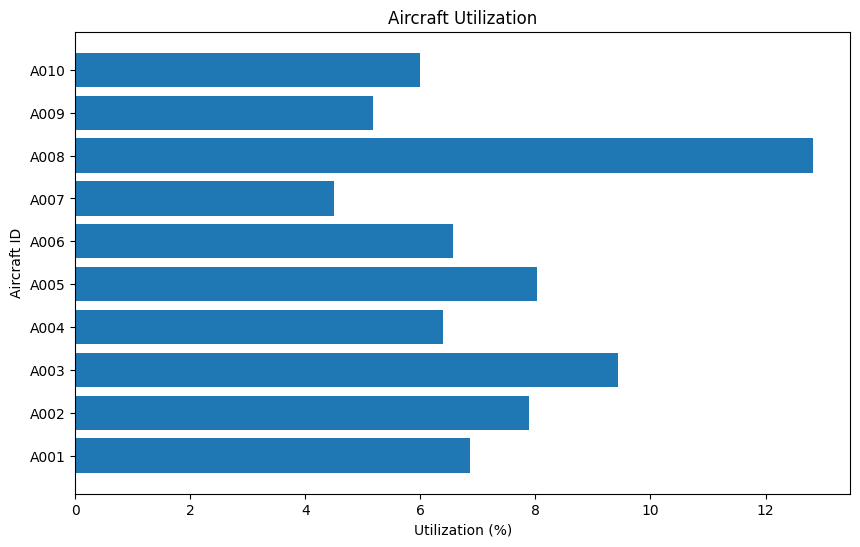

In [67]:
import matplotlib.pyplot as plt

sorties = pd.read_csv("data/cleaned_sorties.csv")

aircraft = pd.read_csv("data/cleaned_aircraft.csv")

sorties["actual_start"] = pd.to_datetime(
    sorties["actual_start"],
    errors="coerce"
)

sorties["actual_end"] = pd.to_datetime(
    sorties["actual_end"],
    errors="coerce"
)

sorties["flight_duration_hours"] = (
    (
        sorties["actual_end"] -
        sorties["actual_start"]
    ).dt.total_seconds())/3600

aircraft_hours = sorties.groupby(
    "aircraft_id"
)["flight_duration_hours"].sum().reset_index()


aircraft_utilization = aircraft.merge(
    aircraft_hours,
    on="aircraft_id",
    how="left"
)

aircraft_utilization[
    "flight_duration_hours"
] = aircraft_utilization[
    "flight_duration_hours"
].fillna(0)


aircraft_utilization[
    "utilization_percent"
] = (aircraft_utilization["flight_duration_hours"]/aircraft_utilization["total_available_hours"])*100


plt.figure(figsize=(10,6))

plt.barh(
    aircraft_utilization["aircraft_id"],
    aircraft_utilization["utilization_percent"]
)

plt.xlabel("Utilization (%)")
plt.ylabel("Aircraft ID")
plt.title("Aircraft Utilization")

plt.savefig(
    "charts/aircraft_utilization.png",
    bbox_inches="tight"
)

plt.show()

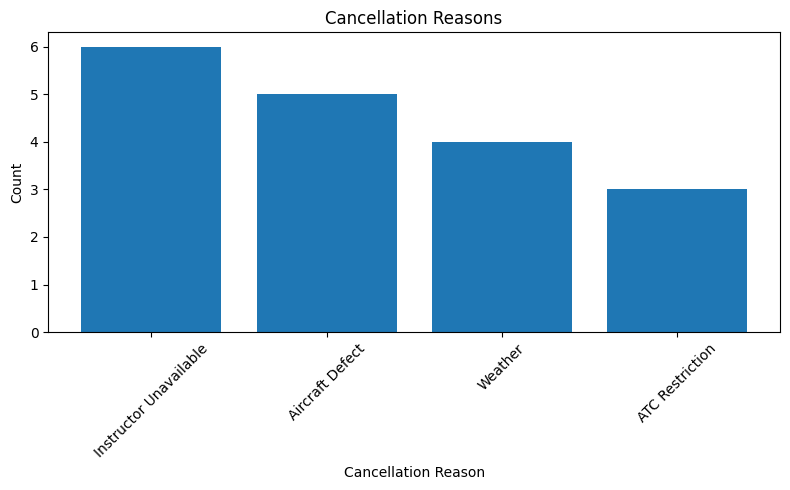

In [68]:
sorties = pd.read_csv(
    "data/cleaned_sorties.csv"
)

cancel_reasons = sorties[
    sorties["status"]=="cancelled"
]["cancel_reason"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    cancel_reasons.index,
    cancel_reasons.values
)

plt.xticks(rotation=45)

plt.xlabel("Cancellation Reason")
plt.ylabel("Count")
plt.title("Cancellation Reasons")

plt.tight_layout()

plt.savefig(
    "charts/cancellation_reasons.png"
)

plt.show()

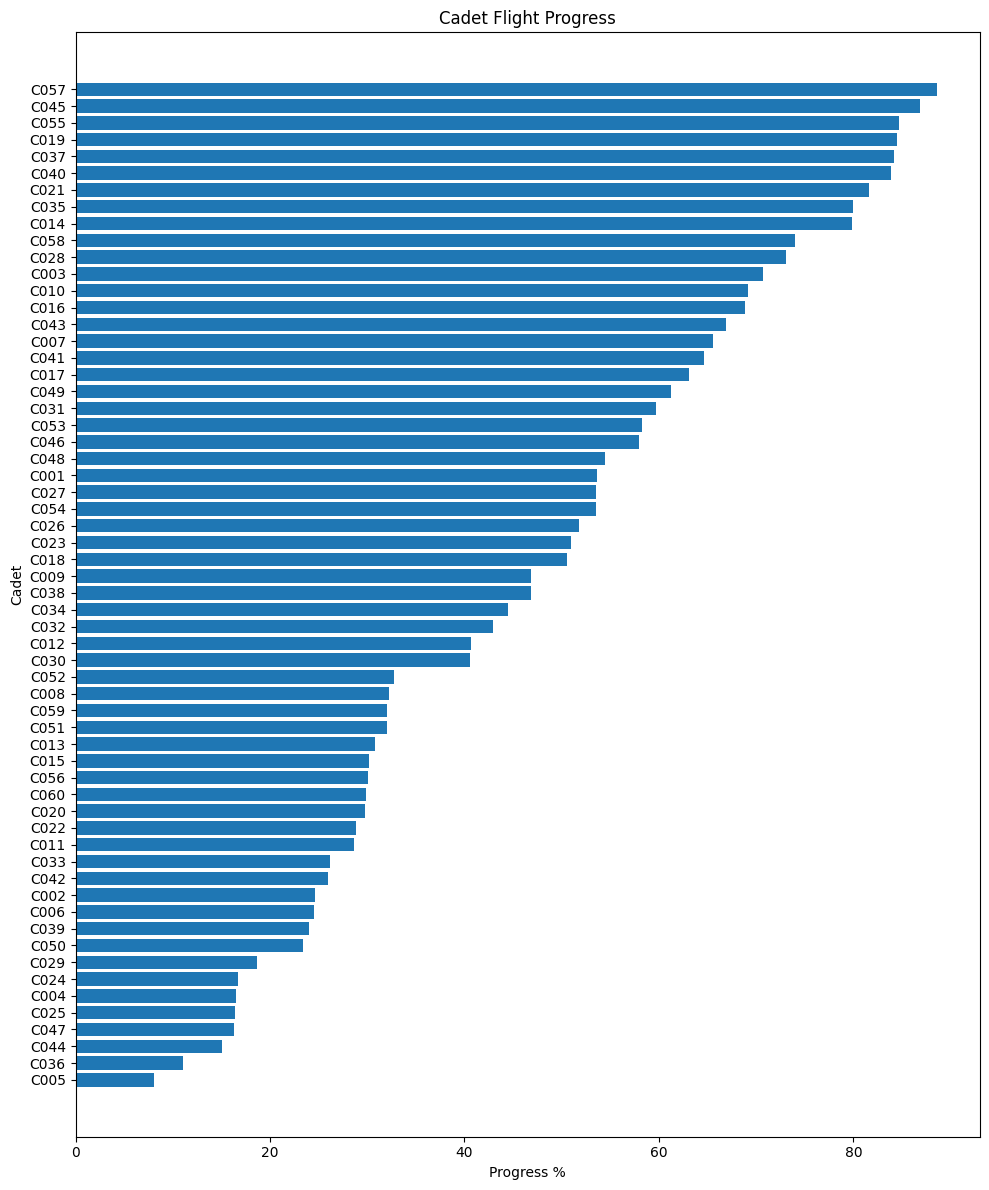

In [69]:
cadets = pd.read_csv(
    "data/cleaned_cadets.csv"
)

cadets["progress"]=(

cadets["total_flown_hours"]

/

cadets["total_required_hours"]

)*100


cadets = cadets.sort_values(
    "progress"
)

plt.figure(figsize=(10,12))

plt.barh(
    cadets["cadet_id"],
    cadets["progress"]
)

plt.xlabel("Progress %")
plt.ylabel("Cadet")
plt.title("Cadet Flight Progress")

plt.tight_layout()

plt.savefig(
    "charts/cadet_progress.png"
)

plt.show()

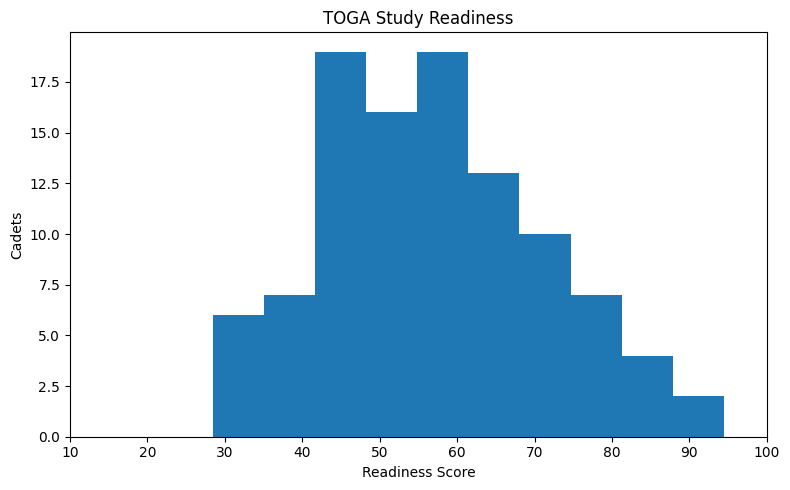

In [84]:
toga = pd.read_csv(
    "data/cleaned_toga_study.csv"
)

toga["study_readiness"]=(
(toga["chapters_completed"]/
toga["total_chapters"])*40+
toga["avg_quiz_score"]*0.4+
(toga["practice_tests_attempted"]/10)*20)

toga["study_readiness"] = (
    toga["study_readiness"]
).clip(0,100)

plt.figure(figsize=(8,5))

plt.hist(
    toga["study_readiness"],
    bins=10
)
plt.xticks(
    range(10,101,10)
)

plt.xlabel("Readiness Score")
plt.ylabel("Cadets")
plt.title("TOGA Study Readiness")

plt.tight_layout()

plt.savefig(
    "charts/study_readiness.png"
)

plt.show()

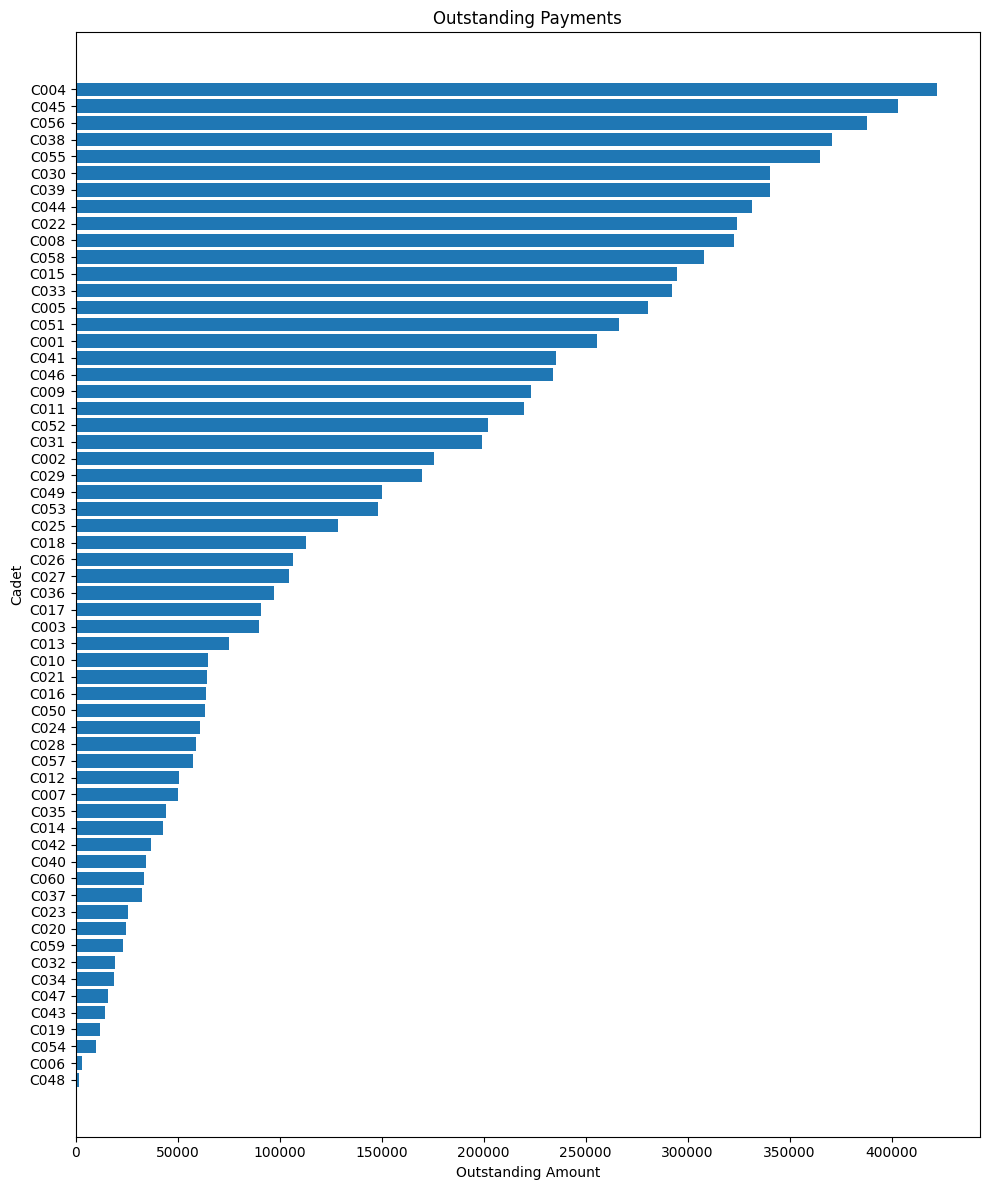

In [79]:
payments = pd.read_csv(
    "data/cleaned_payments.csv"
)

payments=payments.sort_values(
    "outstanding_amount"
)

plt.figure(figsize=(10,12))

plt.barh(
    payments["cadet_id"],
    payments["outstanding_amount"]
)

plt.xlabel("Outstanding Amount")
plt.ylabel("Cadet")
plt.title("Outstanding Payments")

plt.tight_layout()

plt.savefig(
    "charts/payment_risk.png"
)

plt.show()

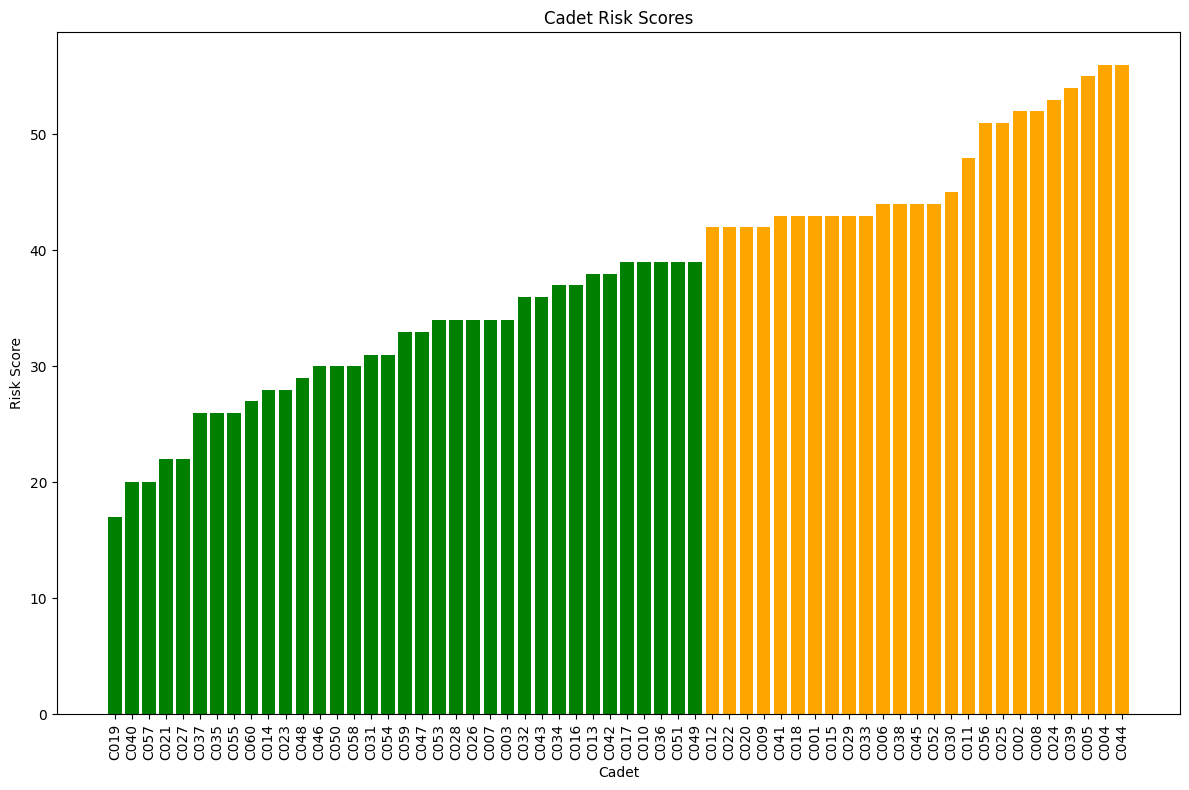

In [80]:
risk = pd.read_csv(
    "data/risk_scores.csv"
)

risk = risk.sort_values(
    "risk_score"
)


colors=[]

for i in risk["risk_level"]:

    if i=="Low":
        colors.append("green")

    elif i=="Medium":
        colors.append("orange")

    else:
        colors.append("red")


plt.figure(figsize=(12,8))

plt.bar(
    risk["cadet_id"],
    risk["risk_score"],
    color=colors
)

plt.xticks(rotation=90)

plt.xlabel("Cadet")
plt.ylabel("Risk Score")
plt.title("Cadet Risk Scores")

plt.tight_layout()

plt.savefig(
    "charts/cadet_risk_scores.png"
)

plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_61244\2592257928.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


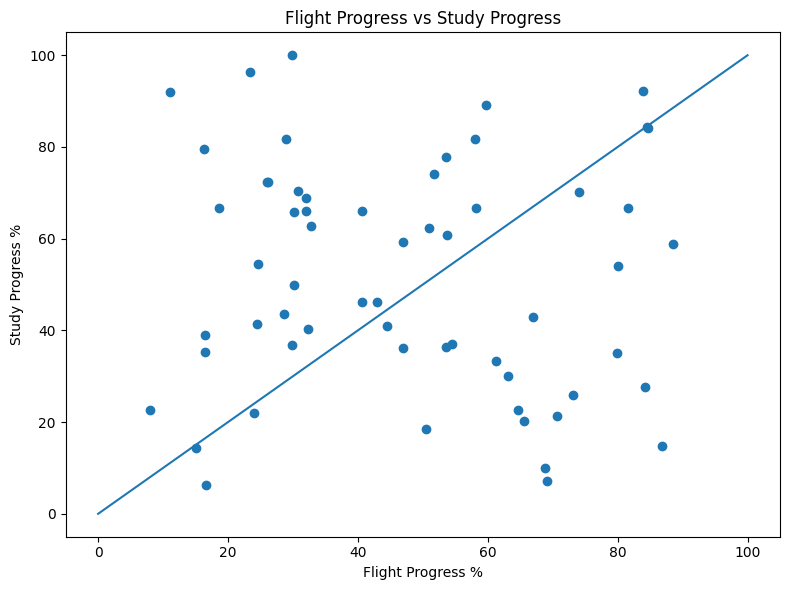

In [81]:
cadets = pd.read_csv(
    "data/cleaned_cadets.csv"
)

toga = pd.read_csv(
    "data/cleaned_toga_study.csv"
)

cadets["flight_progress"]=(

cadets["total_flown_hours"]

/

cadets["total_required_hours"]

)*100


study=toga.groupby(
    "cadet_id"
).apply(

lambda x:

(
x["chapters_completed"].sum()

/

x["total_chapters"].sum()

)*100

).reset_index(
    name="study_progress"
)


combined=cadets.merge(
    study,
    on="cadet_id"
)

plt.figure(figsize=(8,6))

plt.scatter(

combined["flight_progress"],

combined["study_progress"]

)

plt.plot(
    [0,100],
    [0,100]
)

plt.xlabel(
    "Flight Progress %"
)

plt.ylabel(
    "Study Progress %"
)

plt.title(
    "Flight Progress vs Study Progress"
)

plt.tight_layout()

plt.savefig(
    "charts/flight_vs_study_progress.png"
)

plt.show()